In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib as plt
import seaborn as sns

**pclass**: A proxy for socio-economic status (SES)
1st = Upper
2nd = Middle
3rd = Lower

**age**: Age is fractional if less than 1. If the age is estimated, is it in the form of xx.5

**sibsp**: The dataset defines family relations in this way...
**Sibling** = brother, sister, stepbrother, stepsister
**Spouse** = husband, wife (mistresses and fiancés were ignored)

**parch**: The dataset defines family relations in this way...
Parent = mother, father
Child = daughter, son, stepdaughter, stepson
Some children travelled only with a nanny, therefore parch=0 for them.

In [2]:
datapath = '/home/sidyaniv/Desktop/projects/kaggle_competitions/titanic/dataset/titanic'
gender_submission_name = 'gender_submission.csv'
test_name = 'test.csv'
train_name = 'train.csv'

target_data = pd.read_csv(os.path.join(datapath, gender_submission_name), index_col='PassengerId')
test_data = pd.read_csv(os.path.join(datapath, test_name), index_col='PassengerId')
train_data  = pd.read_csv(os.path.join(datapath, train_name), index_col='PassengerId')

In [3]:
useless_names = ['Name', 'Ticket', 'Cabin']     # Удаляем Cabin так как она почти пустая. Остальное - не нужно

train_data.drop(columns=useless_names, inplace=True)
test_data.drop(columns=useless_names, inplace=True)

In [4]:
# Rename columns
rename = {'SibSp': 'br_sister_partner', 'Parch': 'parents_childs', 
          'Fare': 'ticket_cost', 'Embarked': 'port_name'}
train_data.rename(columns=rename, inplace=True)
test_data.rename(columns=rename, inplace=True)

In [18]:
test_data.head()
target_data.head()

,Survived
PassengerId,
892,0
893,1
894,0
895,0
896,1


In [5]:
# 1)Sex можно закодировать через one-hot encoding, тк. всего 2 класса
# 2)Pclass можно как-то закодировать через количество/долю выживших этого класса
# 3)Cabin можно как-то закодировать через количество/долю выживших этого класса
# 4)port_name можно как-то закодировать через количество/долю выживших этого класса
# 5)Удалю все объекты с пропусками для baseline

train_cleared = train_data.dropna(subset=['Age', 'port_name', 'ticket_cost'])
test_cleared = test_data.dropna(subset=['Age', 'port_name', 'ticket_cost'])

# train_cleared.info()
# train_data.info()

1) Сначала загоним данные без нормировки, самым деревянным способом (через легкие кодировки)

In [6]:
train_data['port_name'].isna().count()
test_data['port_name'].isna().count()

np.int64(418)

/tmp/ipykernel_17506/1128537366.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data=train_cleared, x='Sex',  kind='count', palette = custom_colors)
/tmp/ipykernel_17506/1128537366.py:3: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.catplot(data=train_cleared, x='Sex',  kind='count', palette = custom_colors)
/tmp/ipykernel_17506/1128537366.py:5: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.catplot(data=train_cleared, x = 'Pclass', hue='Sex', kind='count', palette = custom_colors)


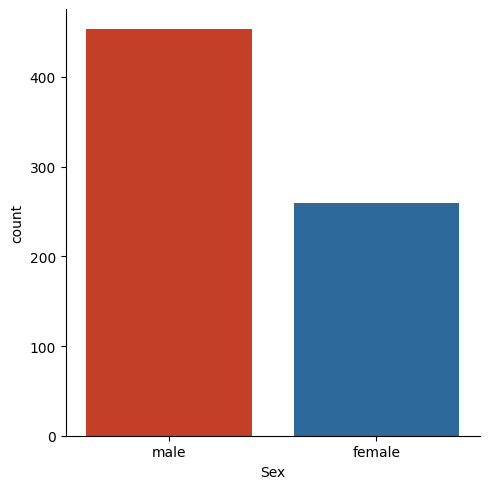

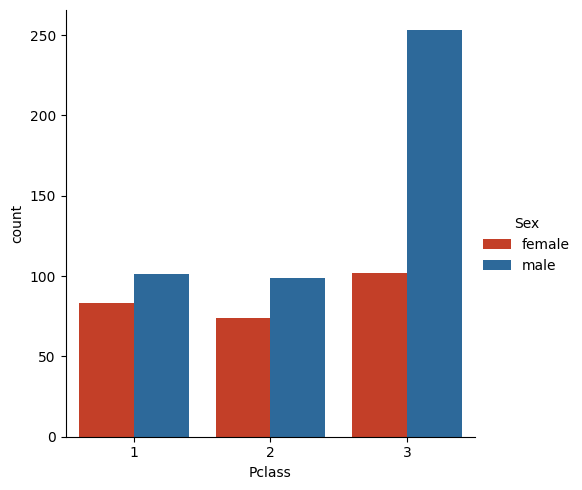

In [7]:
# Visualization
custom_colors = ["#DD2D0E", "#1B6BAC", "#C504BB"]
sns.catplot(data=train_cleared, x='Sex',  kind='count', palette = custom_colors)
# sns.catplot(data=train_cleared, x='Pclass', hue='Sex', kind='count', palette = custom_colors)
sns.catplot(data=train_cleared, x = 'Pclass', hue='Sex', kind='count', palette = custom_colors)

1) Больше мужчин, чем женщин
2) Мужчин в бедных каютах в ~2 раза больше чем женщин. В других классах ситуация примерно равная.

/tmp/ipykernel_17506/1158342737.py:1: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.catplot(data=train_cleared, x = 'Pclass', hue='Survived', kind='count', palette = custom_colors)


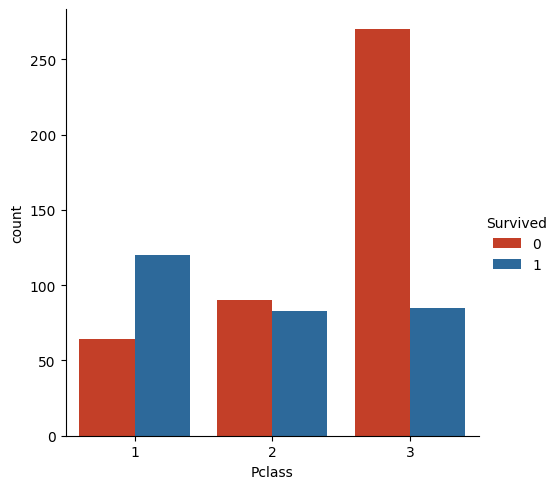

In [8]:
sns.catplot(data=train_cleared, x = 'Pclass', hue='Survived', kind='count', palette = custom_colors)

Процент выживших гораздо больше в 1 и 2 классе

/tmp/ipykernel_17506/3066125153.py:1: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.catplot(data=train_cleared, x = 'br_sister_partner', hue='Survived', kind='count', palette = custom_colors)
/tmp/ipykernel_17506/3066125153.py:2: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.catplot(data=train_cleared, x = 'parents_childs', hue='Survived', kind='count', palette = custom_colors)


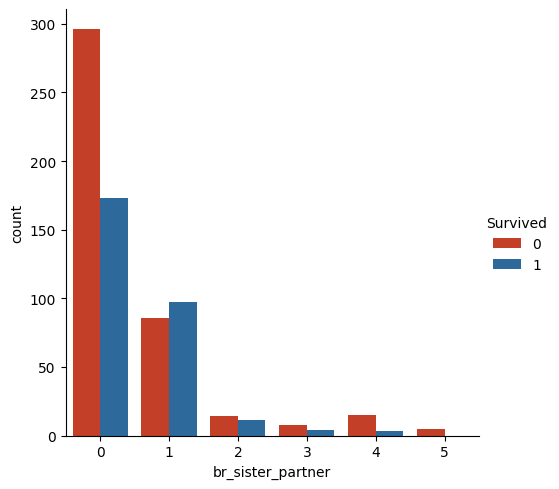

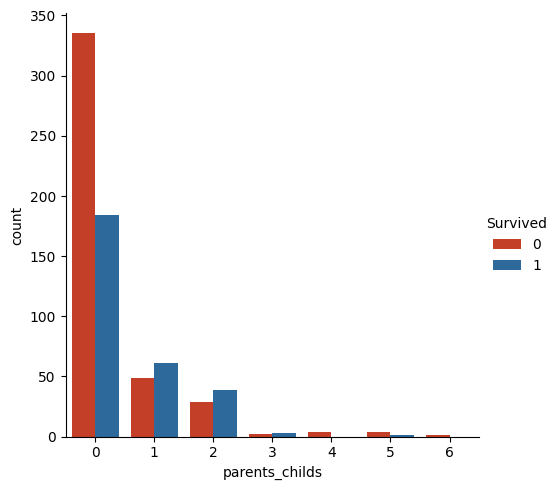

In [9]:
sns.catplot(data=train_cleared, x = 'br_sister_partner', hue='Survived', kind='count', palette = custom_colors)
sns.catplot(data=train_cleared, x = 'parents_childs', hue='Survived', kind='count', palette = custom_colors)

При отсутствии родственников больший процент умирал. Видимо, они спасали друг друга. При большой семье выживало меньшинство (1-2 человека)

/tmp/ipykernel_17506/3563163450.py:1: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.catplot(data=train_cleared, x = 'Sex', hue='Survived', kind='count', palette = custom_colors)


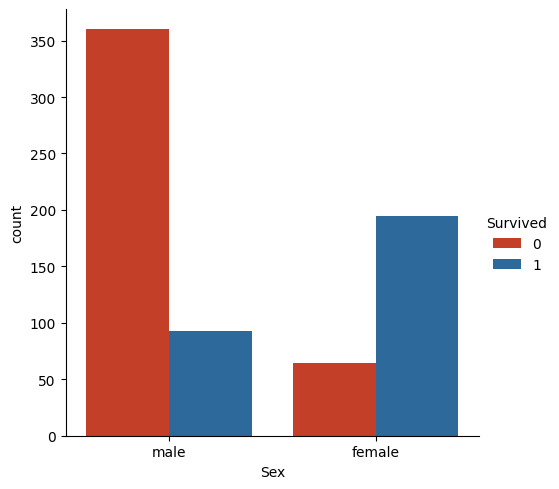

In [10]:
sns.catplot(data=train_cleared, x = 'Sex', hue='Survived', kind='count', palette = custom_colors)

В процентах мужчин погибло гораздо больше чем женщин (то есть женщин спасали первоочерёдно)

In [11]:
from sklearn.preprocessing import OneHotEncoder
one_hot_encoder = OneHotEncoder(sparse_output=False)

# enoding
train_copy = train_cleared.copy()
test_copy = test_cleared.copy()

# Pclass
mean_target_Pclass = train_copy.groupby('Pclass')['Survived'].mean()

mapping_train = mean_target_Pclass.to_dict()
mapping_test = mean_target_Pclass.to_dict()

train_copy['encoded_Pclass'] = train_copy['Pclass'].map(mapping_train)
test_copy['encoded_Pclass'] = test_copy['Pclass'].map(mapping_test)

train_copy.drop(['Pclass'], axis=1, inplace=True)
test_copy.drop(['Pclass'], axis=1, inplace=True)

In [12]:
# Sex
encode_columns = ['port_name', 'Sex']

train_copy = pd.get_dummies(train_copy, columns=encode_columns, drop_first=True)
test_copy = pd.get_dummies(test_copy, columns=encode_columns, drop_first=True)

train_copy[['port_name_Q', 'port_name_S', 'Sex_male']] = train_copy[['port_name_Q', 'port_name_S', 'Sex_male']].astype(int)

In [13]:
train_cleared.head()
train_copy.head()

,Survived,Age,br_sister_partner,parents_childs,ticket_cost,encoded_Pclass,port_name_Q,port_name_S,Sex_male
PassengerId,,,,,,,,,
1,0,22.0,1,0,7.2500,0.239437,0,1,1
2,1,38.0,1,0,71.2833,0.652174,0,0,0
3,1,26.0,0,0,7.9250,0.239437,0,1,0
4,1,35.0,1,0,53.1000,0.652174,0,1,0
5,0,35.0,0,0,8.0500,0.239437,0,1,1


In [19]:
X_train = train_copy.drop(['Survived'], axis=1)
y_train = train_copy['Survived']

X_test = test_copy.copy()
y_test = target_data['Survived']

In [ ]:
from sklearn.linear_model import LogisticRegression

model_logistic_regr = LogisticRegression(penalty='l2', max_iter=100, )
model_logistic_regr.fit(X_train, y_train)

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, precision_score



In [ ]:
def make_prediction_csv(prediction, test_data, filename='preds.csv', dirname='predictions'):
    if not os.path.exists(dirname):
        os.mkdir(dirname)
    save_path = os.path.join(dirname, filename)

    predictions_df = pd.DataFrame({'PassengerId': test_data.reset_index()['PassengerId'] ,'Survived': prediction})
    predictions_csv = predictions_df.to_csv(save_path, index=False)
    return predictions_csv

# make_prediction_csv()
    